# Polynomail Model

In [58]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [59]:
X = np.random.rand(100, 1)
y = 500 * X ** 4 + 8 * X **3 +2 * X ** 2 + 3 * X + np.random.rand(100, 1) * 100
# y = y.ravel()

X.shape, y.shape

((100, 1), (100, 1))

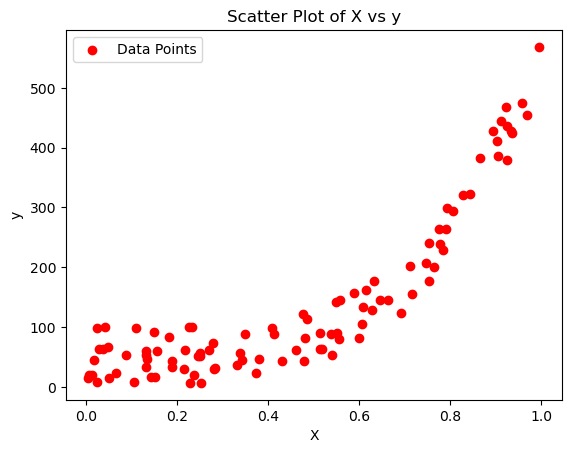

In [60]:
plt.scatter(X, y, color="red", label="Data Points")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Scatter Plot of X vs y")
plt.show()


In [61]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Step 1: Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Scale the features (standardize)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # use transform only here

# (Optional) Check shapes
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)


X_train_scaled shape: (80, 1)
X_test_scaled shape: (20, 1)


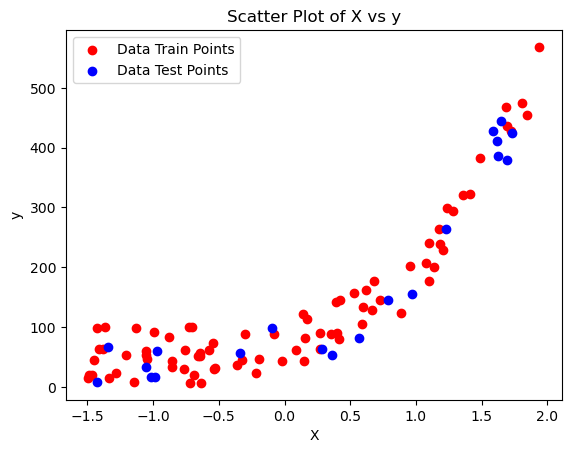

In [62]:
plt.scatter(X_train_scaled, y_train, color="red", label="Data Train Points")
plt.scatter(X_test_scaled, y_test, color="blue", label="Data Test Points")

plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Scatter Plot of X vs y")
plt.show()


## Linear Regression model (Simple Model)

In [63]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Train the model
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

# Predict on test set
y_pred = linear_model.predict(X_test_scaled)

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Root Mean Squared Error
rmse = np.sqrt(mse)

# R² Score
r2 = r2_score(y_test, y_pred)

# Adjusted R² Score
n = X_test.shape[0]  # number of samples
p = X_test.shape[1]  # number of features
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Print all metrics
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"Adjusted R² Score: {adjusted_r2:.4f}")


Mean Squared Error (MSE): 6294.63
Root Mean Squared Error (RMSE): 79.34
R² Score: 0.7619
Adjusted R² Score: 0.7487


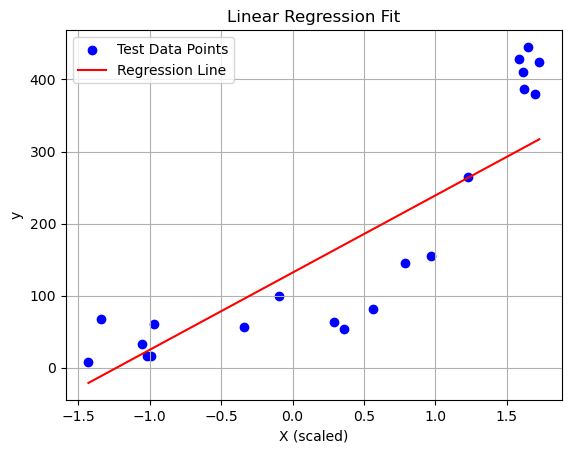

In [64]:
import numpy as np
import matplotlib.pyplot as plt

# Generate a sequence of evenly spaced values for plotting the regression line
new_X = np.linspace(X_test_scaled.min(), X_test_scaled.max(), 100).reshape(-1, 1)

# Predict using the model
y_line = linear_model.predict(new_X)

# Plot the actual test data
plt.scatter(X_test_scaled, y_test, color="blue", label="Test Data Points")

# Plot the regression line
plt.plot(new_X, y_line, color="red", label="Regression Line")

# Labels and title
plt.xlabel("X (scaled)")
plt.ylabel("y")
plt.legend()
plt.title("Linear Regression Fit")
plt.grid(True)
plt.show()


## Polynomial Linear Model

In [77]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Polynomial transformation
poly = PolynomialFeatures(degree=5, include_bias=True)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# Step 2: Train a linear regression model on polynomial features
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Step 3: Predict
y_pred_poly = poly_model.predict(X_test_poly)

# Step 4: Evaluation metrics
mse = mean_squared_error(y_test, y_pred_poly)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_poly)

# Adjusted R²
n = X_test_poly.shape[0]
p = X_test_poly.shape[1] - 1  # exclude bias
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Print metrics
print(f"Polynomial Regression (degree=2)")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"Adjusted R² Score: {adjusted_r2:.4f}")

# Print intercept
print("Intercept:", float(poly_model.intercept_))

# Print coefficients
coefficients = list(poly_model.coef_)
# Fix the shape issue
coefficients = poly_model.coef_.ravel()  # or: poly_model.coef_[0]
print("Coefficients:", coefficients.tolist())
print("Total Coefficients (including bias):", len(coefficients))



Polynomial Regression (degree=2)
Mean Squared Error (MSE): 1005.05
Root Mean Squared Error (RMSE): 31.70
R² Score: 0.9620
Adjusted R² Score: 0.9484
Intercept: 66.36182475075664
Coefficients: [0.0, 63.41815654045419, 69.51704505158528, 7.646825515127901, -5.4503355892190575, 4.499696259933586]
Total Coefficients (including bias): 6


C:\Users\sande\AppData\Local\Temp\ipykernel_2148\3951093371.py:38: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Intercept:", float(poly_model.intercept_))


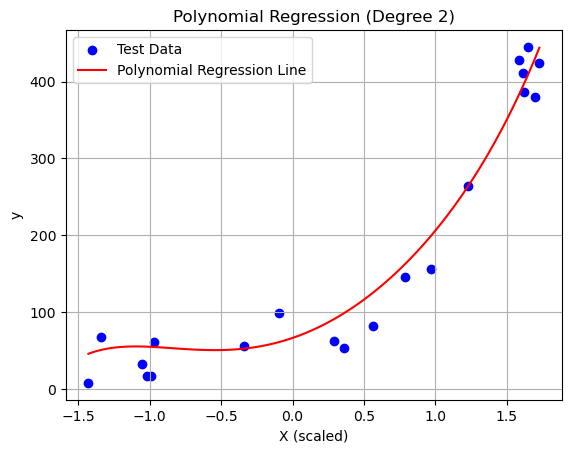

In [75]:
# Step 5: Plot
new_X = np.linspace(X_test_scaled.min(), X_test_scaled.max(), 100).reshape(-1, 1)
new_X_poly = poly.transform(new_X)
y_line = poly_model.predict(new_X_poly)

plt.scatter(X_test_scaled, y_test, color="blue", label="Test Data")
plt.plot(new_X, y_line, color="red", label="Polynomial Regression Line")
plt.xlabel("X (scaled)")
plt.ylabel("y")
plt.title("Polynomial Regression (Degree 2)")
plt.legend()
plt.grid(True)
plt.show()

## Pipeeline Polynomial (Genraic Poynomial)

In [79]:
from sklearn.pipeline import Pipeline

def polynomial_regression_pipeline(X, y, degree=2, test_size=0.2, random_state=42):
    # 1. Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    # 2. Pipeline creation
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("poly_features", PolynomialFeatures(degree=degree, include_bias=True)),
        ("lin_reg", LinearRegression())
    ])

    # 3. Fit the model
    model.fit(X_train, y_train)

    # 4. Predict and evaluate
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    n = X_test.shape[0]
    p = model.named_steps['poly_features'].fit_transform(X_test).shape[1] - 1
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    print(f"\n📈 Polynomial Regression (degree={degree})")
    print(f"Intercept: {model.named_steps['lin_reg'].intercept_.item():.4f}")
    print(f"MSE: {mse:.2f}, RMSE: {rmse:.2f}")
    print(f"R²: {r2:.4f}, Adjusted R²: {adj_r2:.4f}")

    # 5. Print coefficients with feature names
    poly = model.named_steps['poly_features']
    coef = model.named_steps['lin_reg'].coef_.ravel()
    feature_names = poly.get_feature_names_out(["X"])
    print("\n🧮 Coefficients:")
    for name, c in zip(feature_names, coef):
        print(f"{name}: {c:.4f}")

    # 6. Plotting
    X_scaled = model.named_steps['scaler'].transform(X)
    X_range = np.linspace(X_scaled.min(), X_scaled.max(), 100).reshape(-1, 1)
    X_poly = poly.transform(X_range)
    y_line = model.named_steps['lin_reg'].predict(X_poly)

    plt.scatter(model.named_steps['scaler'].transform(X_test), y_test, color="blue", label="Test Data")
    plt.plot(X_range, y_line, color="red", label="Model Prediction")
    plt.title(f"Polynomial Regression Fit (Degree {degree})")
    plt.xlabel("X (scaled)")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True)
    plt.show()

    return model



📈 Polynomial Regression (degree=8)
Intercept: 72.0182
MSE: 1034.42, RMSE: 32.16
R²: 0.9609, Adjusted R²: 0.9324

🧮 Coefficients:
1: 0.0000
X: 88.6627
X^2: 17.3856
X^3: -76.2206
X^4: 75.0144
X^5: 69.2027
X^6: -43.2591
X^7: -14.0209
X^8: 7.8833


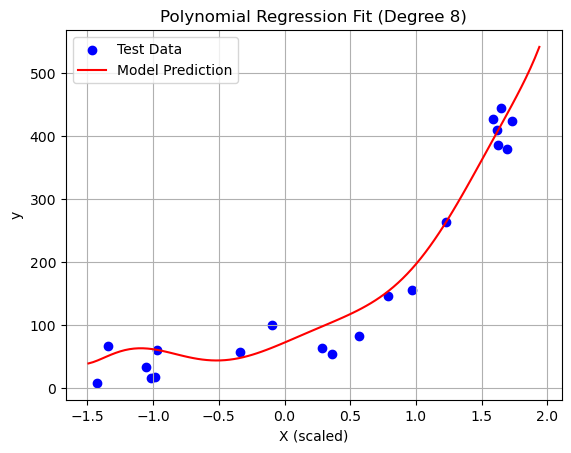

In [81]:
model = polynomial_regression_pipeline(X, y, degree=8)